In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
target_dir = '/global/cfs/cdirs/desi/target/catalogs/dr8'
photoz_dir_north = '/dvs_ro/cfs/cdirs/cosmo/data/legacysurvey/dr8/north/sweep/8.0-photo-z'
photoz_dir_south = '/dvs_ro/cfs/cdirs/cosmo/data/legacysurvey/dr8/south/sweep/8.0-photo-z'
output_dir = '/global/cscratch1/sd/rongpu/target/catalogs/dr8.0/0.42.0/ra_dec_only'

In [4]:
target_class = 'LRG'

target_path_list = glob.glob(os.path.join(target_dir, '0.42.0/targets/main/resolve/dark/targets-dark-hp-*.fits'))
print(len(target_path_list))

target_bits = {'LRG':0, 'ELG':1, 'QSO':2, 'BGS_ANY':60}
target_bit = target_bits[target_class]
target_columns = ['BRICKID', 'BRICK_OBJID', 'MORPHTYPE', 'RA', 'DEC', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FLUX_W1', 'FLUX_W2', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MASKBITS', 'PHOTSYS', 'DESI_TARGET']

#############################################################################

cat = []
for target_path in target_path_list:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    cat.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
cat = vstack(cat)
print(len(cat))

41
/global/cfs/cdirs/desi/target/catalogs/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
0.16157353125229065 504773 3124107
/global/cfs/cdirs/desi/target/catalogs/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-31.fits
0.1533269159699957 245615 1601904
/global/cfs/cdirs/desi/target/catalogs/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-17.fits
0.16139669914048707 516687 3201348
/global/cfs/cdirs/desi/target/catalogs/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-46.fits
0.138326673240265 31985 231228
/global/cfs/cdirs/desi/target/catalogs/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-5.fits
0.14117980400705812 494781 3504616
/global/cfs/cdirs/desi/target/catalogs/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-6.fits
0.1591849734068962 432844 2719126
/global/cfs/cdirs/desi/target/catalogs/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
0.1399325039964739 42542 304018
/global/cfs/cdirs/desi/target/catalogs/dr8/0.42.0/targets/main/

In [5]:
cat.rename_column('BRICK_OBJID', 'OBJID')

cat['id'] = np.array(cat['BRICKID'], dtype=np.int64)*int(1e7) + np.array(cat['OBJID'], dtype=np.int64)

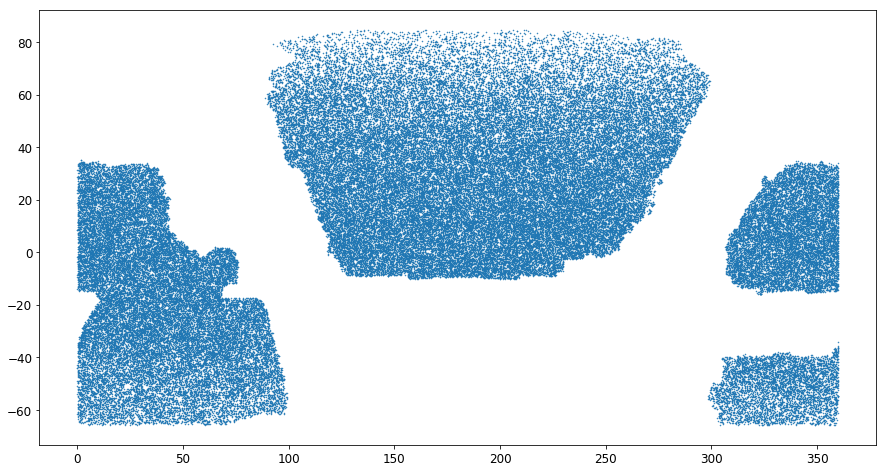

In [6]:
idx = np.random.choice(len(cat), size=len(cat)//100, replace=False)

plt.figure(figsize=(15, 8))
plt.plot(cat['RA'][idx], cat['DEC'][idx], '.', ms=1)
plt.show()

In [7]:
cat_all = cat.copy()

--------
# South

In [8]:
field = 'south'
sweep_dir = '/dvs_ro/cfs/cdirs/cosmo/data/legacysurvey/dr8/{}/sweep/8.0'.format(field)
pz_dir = '/dvs_ro/cfs/cdirs/cosmo/data/legacysurvey/dr8/{}/sweep/8.0-photo-z'.format(field)

if field=='south':
    photsys = 'S'
else:
    photsys = 'N'
    
mask = cat_all['PHOTSYS']==photsys
print(np.sum(mask), np.sum(mask)/len(mask))
cat = cat_all[mask]

8428947 0.740047098512


In [9]:
sweep_paths = glob.glob(os.path.join(sweep_dir, '*.fits'))

pz_all = []
for sweep_index in range(len(sweep_paths)):
        
    sweep_path = sweep_paths[sweep_index]
    pz_path = os.path.join(pz_dir, os.path.basename(sweep_path).replace('.fits', '-pz.fits'))

    brick = sweep_path[-20:-5]
    ramin = float(brick[0:3])
    ramax = float(brick[8:11])
    decmin = float(brick[4:7])
    if brick[3]=='m':
        decmin = -decmin
    decmax = float(brick[-3:])
    if brick[-4]=='m':
        decmax = -decmax
    cat_mask = (cat['RA']<=ramax) & (cat['RA']>=ramin) & (cat['DEC']<=decmax) & (cat['DEC']>=decmin)
    cat_mask &= cat['PHOTSYS']==photsys
    if np.sum(cat_mask)==0:
        continue

    sweep = Table(fitsio.read(sweep_path, columns=['BRICKID', 'OBJID']))
    sweep['id'] = np.array(sweep['BRICKID'], dtype=np.int64)*int(1e7) + np.array(sweep['OBJID'], dtype=np.int64)

    sweep_idx = np.where(np.in1d(sweep['id'], cat['id'][cat_mask]))[0]
    pz = Table(fitsio.read(pz_path, rows=sweep_idx))
    pz['id'] = sweep['id'][sweep_idx]
    print(sweep_index, '/', len(sweep_paths), len(pz), np.sum(cat_mask)-len(pz))
    pz_all.append(pz)
    
pz = vstack(pz_all)
print(len(pz))

0 / 437 12512 0
1 / 437 13439 0
2 / 437 25871 0
3 / 437 26461 0
4 / 437 27955 0
5 / 437 17237 0
6 / 437 25489 0
7 / 437 11927 0
8 / 437 1155 0
9 / 437 6763 0
10 / 437 225 0
11 / 437 29578 0
12 / 437 20350 0
13 / 437 236 0
14 / 437 16679 0
15 / 437 26536 0
16 / 437 27544 0
17 / 437 10578 0
18 / 437 8119 0
19 / 437 17647 0
20 / 437 20740 0
21 / 437 19737 0
22 / 437 30558 0
23 / 437 973 0
24 / 437 16120 0
25 / 437 3540 0
26 / 437 28794 0
27 / 437 29865 0
28 / 437 28074 0
29 / 437 28063 0
30 / 437 9783 0
31 / 437 28277 0
32 / 437 26824 0
33 / 437 25851 0
34 / 437 30040 0
35 / 437 13545 0
36 / 437 19814 0
37 / 437 24338 0
38 / 437 28866 0
39 / 437 17738 0
40 / 437 27013 0
42 / 437 12299 0
43 / 437 29954 0
45 / 437 1317 0
47 / 437 17666 0
48 / 437 15262 0
49 / 437 27336 0
50 / 437 29530 0
51 / 437 8828 0
52 / 437 27848 0
53 / 437 25345 0
54 / 437 27859 0
55 / 437 31654 0
56 / 437 26689 0
57 / 437 20272 0
58 / 437 26775 0
59 / 437 6592 0
60 / 437 20659 0
61 / 437 21487 0
62 / 437 14438 0
63 /

In [10]:
t1_reverse_sort = np.array(cat['id']).argsort().argsort()
pz.sort('id')
pz = pz[t1_reverse_sort]

In [11]:
cat.remove_column('id')
pz.remove_column('id')

In [12]:
cat = hstack([cat, pz])
cat_south = cat.copy()

--------
# North

In [13]:
field = 'north'
sweep_dir = '/dvs_ro/cfs/cdirs/cosmo/data/legacysurvey/dr8/{}/sweep/8.0'.format(field)
pz_dir = '/dvs_ro/cfs/cdirs/cosmo/data/legacysurvey/dr8/{}/sweep/8.0-photo-z'.format(field)

if field=='south':
    photsys = 'S'
else:
    photsys = 'N'
    
mask = cat_all['PHOTSYS']==photsys
print(np.sum(mask), np.sum(mask)/len(mask))
cat = cat_all[mask]

2960797 0.259952901488


In [14]:
sweep_paths = glob.glob(os.path.join(sweep_dir, '*.fits'))

pz_all = []
for sweep_index in range(len(sweep_paths)):
        
    sweep_path = sweep_paths[sweep_index]
    pz_path = os.path.join(pz_dir, os.path.basename(sweep_path).replace('.fits', '-pz.fits'))

    brick = sweep_path[-20:-5]
    ramin = float(brick[0:3])
    ramax = float(brick[8:11])
    decmin = float(brick[4:7])
    if brick[3]=='m':
        decmin = -decmin
    decmax = float(brick[-3:])
    if brick[-4]=='m':
        decmax = -decmax
    cat_mask = (cat['RA']<=ramax) & (cat['RA']>=ramin) & (cat['DEC']<=decmax) & (cat['DEC']>=decmin)
    cat_mask &= cat['PHOTSYS']==photsys
    if np.sum(cat_mask)==0:
        continue

    sweep = Table(fitsio.read(sweep_path, columns=['BRICKID', 'OBJID']))
    sweep['id'] = np.array(sweep['BRICKID'], dtype=np.int64)*int(1e7) + np.array(sweep['OBJID'], dtype=np.int64)

    sweep_idx = np.where(np.in1d(sweep['id'], cat['id'][cat_mask]))[0]
    pz = Table(fitsio.read(pz_path, rows=sweep_idx))
    pz['id'] = sweep['id'][sweep_idx]
    print(sweep_index, '/', len(sweep_paths), len(pz), np.sum(cat_mask)-len(pz))
    pz_all.append(pz)
    
pz = vstack(pz_all)
print(len(pz))

2 / 286 13732 0
3 / 286 19982 0
4 / 286 24093 0
5 / 286 8336 0
6 / 286 6039 0
7 / 286 20532 0
9 / 286 21510 0
12 / 286 20911 0
13 / 286 12353 0
14 / 286 8230 0
15 / 286 13382 0
17 / 286 11085 0
18 / 286 16099 0
19 / 286 11074 0
20 / 286 12832 0
21 / 286 11832 0
22 / 286 8569 0
23 / 286 5909 0
24 / 286 21077 0
25 / 286 6214 0
26 / 286 1701 0
27 / 286 24490 0
28 / 286 24609 0
29 / 286 6121 0
30 / 286 12341 0
31 / 286 23582 0
32 / 286 8361 0
33 / 286 8315 0
35 / 286 2545 0
36 / 286 4506 0
37 / 286 18829 0
38 / 286 15318 0
40 / 286 1584 0
41 / 286 20992 0
43 / 286 19392 0
44 / 286 3089 0
45 / 286 362 0
48 / 286 17619 0
49 / 286 17489 0
50 / 286 19397 0
51 / 286 17949 0
52 / 286 23058 0
53 / 286 25129 0
54 / 286 14456 0
55 / 286 11121 0
56 / 286 13953 0
60 / 286 22561 0
61 / 286 22059 0
62 / 286 13149 0
64 / 286 23813 0
65 / 286 16703 0
66 / 286 8016 0
67 / 286 11538 0
68 / 286 19455 0
69 / 286 19416 0
70 / 286 5676 0
72 / 286 10064 0
73 / 286 7788 0
74 / 286 20285 0
75 / 286 8870 0
76 / 28

In [15]:
t1_reverse_sort = np.array(cat['id']).argsort().argsort()
pz.sort('id')
pz = pz[t1_reverse_sort]

In [16]:
cat.remove_column('id')
pz.remove_column('id')

In [17]:
cat = hstack([cat, pz])
cat_north = cat.copy()

--------
# Combine

In [18]:
cat = vstack([cat_north, cat_south])
print(len(cat))
cat.write('/global/cscratch1/sd/rongpu/target/catalogs/dr8.0/0.42.0/dr8_official_lrg_with_photoz.fits')

11389744
